In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
# define parent folder file
folderpath = "/data/visitor/ihhg69/id13/20260409/PROCESSED_DATA/"
folder = Path(folderpath)
for f in folder.iterdir():
    print(f.name)

dq_pap163
dq_pap217
workflows
pap163
pap217
__van
dq_modernpap
BLA
__CALIB
dq_al2o3
siemens
modernpap
al2o3


In [3]:
sample_folder_name = "dq_modernpap"
sample_folder = os.path.join(folderpath,sample_folder_name)
for f in Path(sample_folder).iterdir():
    print(f.name)

dq_modernpap_roi146589_164517
dq_modernpap_roi146587_164515
dq_modernpap_roi146585_164514
dq_modernpap_roi146588_164516


In [4]:
dataset_folder_name = "dq_modernpap_roi146587_164515"
dataset_folder = os.path.join(sample_folder, dataset_folder_name)
for f in Path(dataset_folder).iterdir():
    print(f.name)

workflows
gallery
dq_modernpap_roi146587_164515.h5


In [5]:
scan_path_name = dataset_folder_name
scan_path = os.path.join(dataset_folder, scan_path_name + ".h5")
with h5py.File(scan_path, 'r') as f:
    def print_tree(name, obj):
        print(name)

    f.visititems(print_tree)

1.1
1.1/eiger_average
1.1/eiger_average/average
1.1/eiger_average/average/2th
1.1/eiger_average/average/average_intensity
1.1/eiger_average/average/reference_alpha_Al2O3
1.1/eiger_average/name
1.1/eiger_diffmap
1.1/eiger_diffmap/configuration
1.1/eiger_diffmap/configuration/data
1.1/eiger_diffmap/configuration/type
1.1/eiger_diffmap/diffmap
1.1/eiger_diffmap/diffmap/2th
1.1/eiger_diffmap/diffmap/ct34
1.1/eiger_diffmap/diffmap/dark_value
1.1/eiger_diffmap/diffmap/intensity
1.1/eiger_diffmap/diffmap/intensity_norm
1.1/eiger_diffmap/diffmap/map
1.1/eiger_diffmap/diffmap/map_norm
1.1/eiger_diffmap/diffmap/xpoints
1.1/eiger_diffmap/diffmap/ypoints
1.1/eiger_diffmap/dim0
1.1/eiger_diffmap/dim1
1.1/eiger_diffmap/dim2
1.1/eiger_diffmap/mask_file
1.1/eiger_diffmap/name
1.1/eiger_diffmap/offset
1.1/eiger_integrate
1.1/eiger_integrate/configuration
1.1/eiger_integrate/configuration/data
1.1/eiger_integrate/configuration/type
1.1/eiger_integrate/integrated
1.1/eiger_integrate/integrated/2th
1.1/ei

In [6]:
twotheta_path = f"/1.1/eiger_integrate/integrated/2th"
intensity_path = f"/1.1/eiger_integrate/integrated/intensity"

with h5py.File(scan_path, 'r') as f:
    x = f[twotheta_path][:]
    patterns = f[intensity_path][:]

In [7]:
print("x shape:", x.shape)
print("patterns shape:", patterns.shape)
print("patterns dtype:", patterns.dtype)

x shape: (1050,)
patterns shape: (51200, 1050)
patterns dtype: float32


In [8]:
n_rows = 320
n_cols = 160

if patterns.ndim == 2:
    n_pixels, n_points = patterns.shape
    
    if n_pixels != n_rows * n_cols:
        raise ValueError(f"Expected {n_rows*n_cols} pixels, but got {n_pixels}")
    
    patterns_map = patterns.reshape(n_rows, n_cols, n_points)

elif patterns.ndim == 3:
    if patterns.shape[0] != n_rows or patterns.shape[1] != n_cols:
        raise ValueError(f"Expected shape ({n_rows}, {n_cols}, n_points), but got {patterns.shape}")
    
    patterns_map = patterns
    n_points = patterns.shape[-1]

else:
    raise ValueError("patterns should be either 2D or 3D")

print("patterns_map shape:", patterns_map.shape)

patterns_map shape: (320, 160, 1050)


In [9]:
from ipywidgets import interact, IntSlider
from matplotlib.widgets import RectangleSelector
%matplotlib widget
# Compute total intensity map once
total_intensity_map = patterns_map.sum(axis=2)

print("patterns_map shape:", patterns_map.shape)
print("total_intensity_map shape:", total_intensity_map.shape)

patterns_map shape: (320, 160, 1050)
total_intensity_map shape: (320, 160)


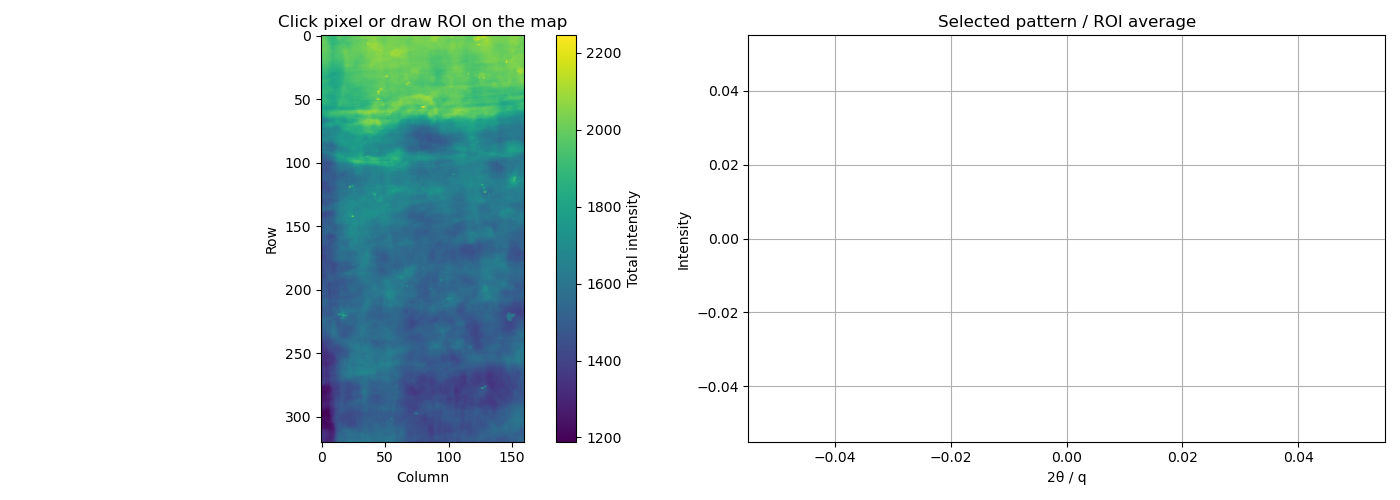

In [10]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
import ipywidgets as widgets
from IPython.display import display

# --------------------------------------------------
# Total intensity map
# --------------------------------------------------
total_intensity_map = patterns_map.sum(axis=2)

# --------------------------------------------------
# Mode selector
# --------------------------------------------------
mode = widgets.ToggleButtons(
    options=["Click pixel", "Draw ROI"],
    value="Click pixel",
    description="Mode:"
)

info = widgets.HTML(value="<b>Mode:</b> Click pixel")
display(widgets.VBox([mode, info]))

# --------------------------------------------------
# Store selected data
# --------------------------------------------------
selected = {
    "type": None,
    "row": None,
    "col": None,
    "row_min": None,
    "row_max": None,
    "col_min": None,
    "col_max": None,
    "pattern": None
}

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D map
im = axes[0].imshow(
    total_intensity_map,
    origin="upper",
    aspect="equal"
)

marker = axes[0].scatter([], [], s=80, marker="x", linewidths=2)

axes[0].set_title("Click pixel or draw ROI on the map")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")
fig.colorbar(im, ax=axes[0], label="Total intensity")

# 1D pattern
line, = axes[1].plot([], [])
axes[1].set_xlabel("2θ / q")
axes[1].set_ylabel("Intensity")
axes[1].set_title("Selected pattern / ROI average")
axes[1].grid()

# --------------------------------------------------
# Click pixel function
# --------------------------------------------------
def onclick(event):
    if mode.value != "Click pixel":
        return

    if event.inaxes != axes[0]:
        return

    if event.xdata is None or event.ydata is None:
        return

    col = int(round(event.xdata))
    row = int(round(event.ydata))

    if row < 0 or row >= patterns_map.shape[0]:
        return
    if col < 0 or col >= patterns_map.shape[1]:
        return

    y = patterns_map[row, col, :]

    # Update marker
    marker.set_offsets([[col, row]])

    # Update pattern
    line.set_data(x, y)
    axes[1].relim()
    axes[1].autoscale_view()

    axes[0].set_title(f"Selected pixel: row={row}, col={col}")
    axes[1].set_title(f"Pattern at row={row}, col={col}")

    selected["type"] = "pixel"
    selected["row"] = row
    selected["col"] = col
    selected["row_min"] = None
    selected["row_max"] = None
    selected["col_min"] = None
    selected["col_max"] = None
    selected["pattern"] = y

    info.value = f"<b>Pixel selected:</b> row={row}, col={col}"

    fig.canvas.draw_idle()

# --------------------------------------------------
# ROI selection function
# --------------------------------------------------
def onselect(eclick, erelease):
    if mode.value != "Draw ROI":
        return

    if eclick.xdata is None or eclick.ydata is None:
        return
    if erelease.xdata is None or erelease.ydata is None:
        return

    col1, row1 = eclick.xdata, eclick.ydata
    col2, row2 = erelease.xdata, erelease.ydata

    col_min = int(np.floor(min(col1, col2)))
    col_max = int(np.ceil(max(col1, col2)))
    row_min = int(np.floor(min(row1, row2)))
    row_max = int(np.ceil(max(row1, row2)))

    # Keep inside map boundaries
    col_min = max(0, col_min)
    col_max = min(patterns_map.shape[1] - 1, col_max)
    row_min = max(0, row_min)
    row_max = min(patterns_map.shape[0] - 1, row_max)

    roi_patterns = patterns_map[row_min:row_max+1, col_min:col_max+1, :]

    # Average ROI pattern
    avg_pattern = roi_patterns.mean(axis=(0, 1))

    # Hide click marker
    marker.set_offsets(np.empty((0, 2)))

    # Update pattern
    line.set_data(x, avg_pattern)
    axes[1].relim()
    axes[1].autoscale_view()

    axes[0].set_title(
        f"ROI: rows {row_min}-{row_max}, cols {col_min}-{col_max}"
    )
    axes[1].set_title(
        f"Average ROI pattern | size = "
        f"{row_max-row_min+1} × {col_max-col_min+1} pixels"
    )

    selected["type"] = "roi"
    selected["row"] = None
    selected["col"] = None
    selected["row_min"] = row_min
    selected["row_max"] = row_max
    selected["col_min"] = col_min
    selected["col_max"] = col_max
    selected["pattern"] = avg_pattern

    info.value = (
        f"<b>ROI selected:</b> rows {row_min}-{row_max}, "
        f"cols {col_min}-{col_max} | "
        f"size = {row_max-row_min+1} × {col_max-col_min+1} pixels"
    )

    fig.canvas.draw_idle()

# --------------------------------------------------
# Rectangle selector for ROI
# --------------------------------------------------
selector = RectangleSelector(
    axes[0],
    onselect,
    useblit=True,
    button=[1],
    minspanx=1,
    minspany=1,
    spancoords="pixels",
    interactive=True
)

# --------------------------------------------------
# Mode change behavior
# --------------------------------------------------
def on_mode_change(change):
    if change["new"] == "Click pixel":
        info.value = "<b>Mode:</b> Click pixel"
    elif change["new"] == "Draw ROI":
        info.value = "<b>Mode:</b> Draw ROI"

mode.observe(on_mode_change, names="value")

# Connect click event
cid = fig.canvas.mpl_connect("button_press_event", onclick)

plt.tight_layout()
plt.show()

In [67]:
def spatial_bin_patterns(patterns_map, bin_size=2, mode="sum"):
    """
    patterns_map shape:
        (n_rows, n_cols, n_points)

    bin_size:
        2 for 2x2 binning
        4 for 4x4 binning

    mode:
        "sum" or "average"
    """

    n_rows, n_cols, n_points = patterns_map.shape

    if n_rows % bin_size != 0 or n_cols % bin_size != 0:
        raise ValueError("n_rows and n_cols must be divisible by bin_size")

    new_rows = n_rows // bin_size
    new_cols = n_cols // bin_size

    blocks = patterns_map.reshape(
        new_rows, bin_size,
        new_cols, bin_size,
        n_points
    )

    if mode == "sum":
        binned_map = blocks.sum(axis=(1, 3))
    elif mode == "average":
        binned_map = blocks.mean(axis=(1, 3))
    else:
        raise ValueError("mode must be 'sum' or 'average'")

    return binned_map

In [68]:
bin_size = 4
bin_mode = "sum"

binned_map = spatial_bin_patterns(
    patterns_map,
    bin_size=bin_size,
    mode=bin_mode
)

print("Original map:", patterns_map.shape)
print("Binned map:", binned_map.shape)

Original map: (320, 160, 1050)
Binned map: (80, 40, 1050)


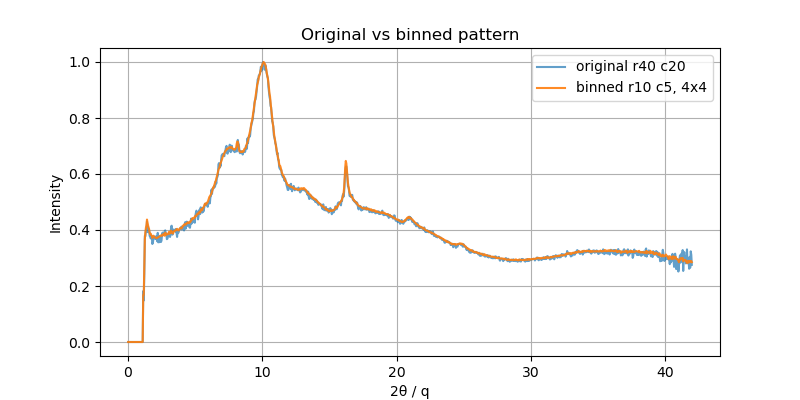

In [69]:
br = 10
bc = 5

original_r0 = br * bin_size
original_c0 = bc * bin_size

y_original = patterns_map[original_r0, original_c0, :]
y_binned = binned_map[br, bc, :]

plt.figure(figsize=(8, 4))

# Plot one original pixel from the block
plt.plot(
    x,
    y_original / np.max(y_original),
    label=f"original r{original_r0} c{original_c0}",
    alpha=0.7
)

# Plot binned pattern
plt.plot(
    x,
    y_binned / np.max(y_binned),
    label=f"binned r{br} c{bc}, {bin_size}x{bin_size}",
    alpha=0.9
)

plt.xlabel("2θ / q")
plt.ylabel("Intensity")
plt.title("Original vs binned pattern")
plt.legend()
plt.grid()
plt.show()

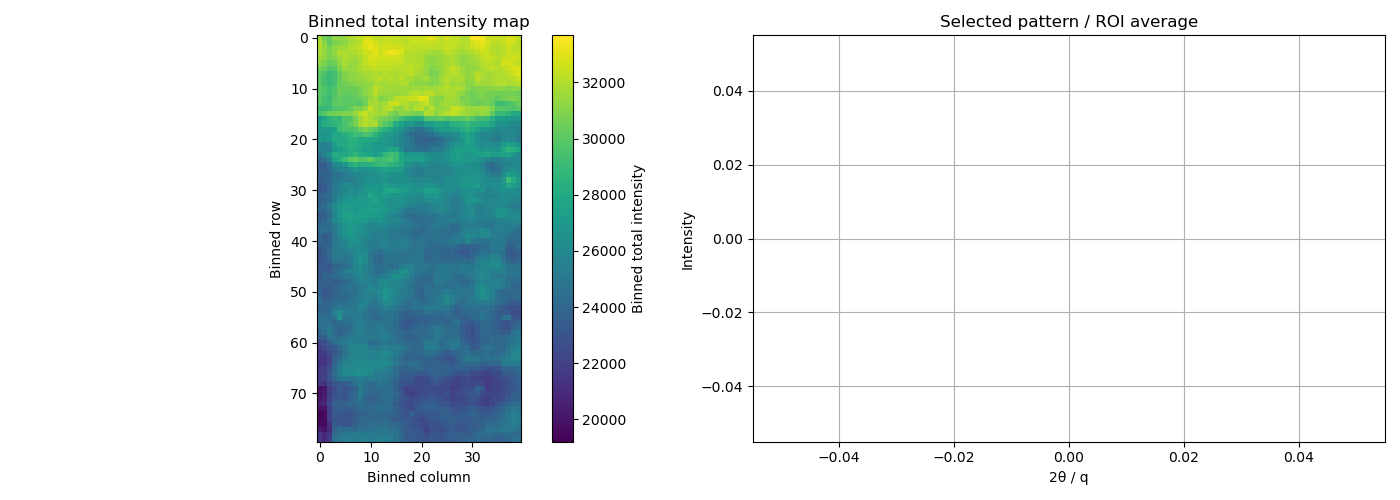

In [70]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
import ipywidgets as widgets
from IPython.display import display

# --------------------------------------------------
# Binned total intensity map
# --------------------------------------------------
binned_total_map = binned_map.sum(axis=2)

# --------------------------------------------------
# Widgets
# --------------------------------------------------
mode = widgets.ToggleButtons(
    options=["Click pixel", "Draw ROI"],
    value="Click pixel",
    description="Mode:"
)

info = widgets.HTML(value="<b>Mode:</b> Click pixel")

display(widgets.VBox([mode, info]))

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 2D map
im = axes[0].imshow(
    binned_total_map,
    origin="upper",
    aspect="equal"
)
axes[0].set_title("Binned total intensity map")
axes[0].set_xlabel("Binned column")
axes[0].set_ylabel("Binned row")
fig.colorbar(im, ax=axes[0], label="Binned total intensity")

# marker for click mode
marker = axes[0].scatter([], [], s=100, marker="x", linewidths=2)

# Right: pattern plot
line, = axes[1].plot([], [])
axes[1].set_xlabel("2θ / q")
axes[1].set_ylabel("Intensity")
axes[1].set_title("Selected pattern / ROI average")
axes[1].grid()

# store last selection
selection = {
    "type": None,
    "row": None,
    "col": None,
    "row_min": None,
    "row_max": None,
    "col_min": None,
    "col_max": None,
    "pattern": None
}

# --------------------------------------------------
# Click handler
# --------------------------------------------------
def onclick(event):
    if mode.value != "Click pixel":
        return
    if event.inaxes != axes[0]:
        return
    if event.xdata is None or event.ydata is None:
        return

    col = int(round(event.xdata))
    row = int(round(event.ydata))

    if not (0 <= row < binned_map.shape[0] and 0 <= col < binned_map.shape[1]):
        return

    y = binned_map[row, col, :]

    marker.set_offsets([[col, row]])
    line.set_data(x, y)
    axes[1].relim()
    axes[1].autoscale_view()

    r0 = row * bin_size
    r1 = r0 + bin_size - 1
    c0 = col * bin_size
    c1 = c0 + bin_size - 1

    axes[0].set_title(f"Binned map | selected pixel: row={row}, col={col}")
    axes[1].set_title(
        f"Binned pattern: row={row}, col={col}\n"
        f"Original region: rows {r0}-{r1}, cols {c0}-{c1}"
    )

    selection["type"] = "pixel"
    selection["row"] = row
    selection["col"] = col
    selection["pattern"] = y

    info.value = (
        f"<b>Pixel selected:</b> binned row={row}, col={col} "
        f"| original rows {r0}-{r1}, cols {c0}-{c1}"
    )

    fig.canvas.draw_idle()

# --------------------------------------------------
# ROI handler
# --------------------------------------------------
def onselect(eclick, erelease):
    if mode.value != "Draw ROI":
        return
    if eclick.xdata is None or eclick.ydata is None:
        return
    if erelease.xdata is None or erelease.ydata is None:
        return

    col1, row1 = eclick.xdata, eclick.ydata
    col2, row2 = erelease.xdata, erelease.ydata

    col_min = max(0, int(np.floor(min(col1, col2))))
    col_max = min(binned_map.shape[1] - 1, int(np.ceil(max(col1, col2))))
    row_min = max(0, int(np.floor(min(row1, row2))))
    row_max = min(binned_map.shape[0] - 1, int(np.ceil(max(row1, row2))))

    roi_patterns = binned_map[row_min:row_max+1, col_min:col_max+1, :]
    avg_pattern = roi_patterns.mean(axis=(0, 1))

    marker.set_offsets(np.empty((0, 2)))  # hide click marker in ROI mode
    line.set_data(x, avg_pattern)
    axes[1].relim()
    axes[1].autoscale_view()

    axes[0].set_title(
        f"ROI: rows {row_min}-{row_max}, cols {col_min}-{col_max}"
    )
    axes[1].set_title(
        f"Average ROI pattern | size = {row_max-row_min+1} x {col_max-col_min+1}"
    )

    selection["type"] = "roi"
    selection["row_min"] = row_min
    selection["row_max"] = row_max
    selection["col_min"] = col_min
    selection["col_max"] = col_max
    selection["pattern"] = avg_pattern

    info.value = (
        f"<b>ROI selected:</b> rows {row_min}-{row_max}, cols {col_min}-{col_max}"
    )

    fig.canvas.draw_idle()

# --------------------------------------------------
# Rectangle selector
# --------------------------------------------------
selector = RectangleSelector(
    axes[0],
    onselect,
    useblit=True,
    button=[1],
    minspanx=1,
    minspany=1,
    spancoords="pixels",
    interactive=True
)

# --------------------------------------------------
# Mode change behavior
# --------------------------------------------------
def on_mode_change(change):
    if change["new"] == "Click pixel":
        info.value = "<b>Mode:</b> Click pixel"
    else:
        info.value = "<b>Mode:</b> Draw ROI"

mode.observe(on_mode_change, names="value")

# connect click
cid = fig.canvas.mpl_connect("button_press_event", onclick)

plt.tight_layout()
plt.show()

In [71]:
parent_folder = r"/home/esrf/tran/grouped_data" 
output_folder = os.path.join(parent_folder, sample_folder_name, dataset_folder_name)
print(output_folder)
os.makedirs(output_folder, exist_ok = True)

/home/esrf/tran/grouped_data/dq_modernpap/dq_modernpap_roi146587_164515


In [72]:
prefix = "pap"

new_rows, new_cols, n_points = binned_map.shape

for r in range(new_rows):
    for c in range(new_cols):
        y = binned_map[r, c, :]
        xy = np.column_stack([x, y])

        idx = r * new_cols + c

        filename = (
            f"{prefix}_bin{bin_size}x{bin_size}"
            f"_r{r:03d}_c{c:03d}"
            f"_idx{idx:05d}.xy"
        )

        output_path = os.path.join(output_folder, filename)

        np.savetxt(
            output_path,
            xy,
            fmt="%.8e",
            comments=""
        )

print(f"Done. Saved {new_rows * new_cols} files in:")
print(output_folder)

Done. Saved 3200 files in:
/home/esrf/tran/grouped_data/dq_modernpap/dq_modernpap_roi146587_164515


In [37]:
files = sorted(Path(output_folder).glob("*.xy"))

print("Number of .xy files:", len(files))
print("First 5 files:")
for f in files[:5]:
    print(f.name)

print("\nLast 5 files:")
for f in files[-5:]:
    print(f.name)

Number of .xy files: 4400
First 5 files:
pap_bin4x4_r000_c000_idx00000.xy
pap_bin4x4_r000_c001_idx00001.xy
pap_bin4x4_r000_c002_idx00002.xy
pap_bin4x4_r000_c003_idx00003.xy
pap_bin4x4_r000_c004_idx00004.xy

Last 5 files:
pap_bin4x4_r109_c035_idx04395.xy
pap_bin4x4_r109_c036_idx04396.xy
pap_bin4x4_r109_c037_idx04397.xy
pap_bin4x4_r109_c038_idx04398.xy
pap_bin4x4_r109_c039_idx04399.xy


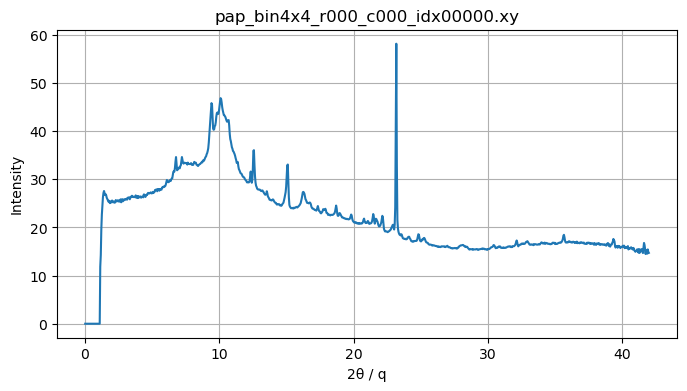

In [38]:
test_file = files[0]

data = np.loadtxt(test_file, skiprows=1)

plt.figure(figsize=(8, 4))
plt.plot(data[:, 0], data[:, 1])
plt.xlabel("2θ / q")
plt.ylabel("Intensity")
plt.title(test_file.name)
plt.grid()
plt.show()